In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nathaniel/uci-online-retail-ii-data-set/online_retail_II.xlsx


## Project Workflow
1. Import dataset
2. Data inspection
3. Missing value analysis
4. Duplicate removal
5. Handle cancellations and invalid quantities/prices
6. Feature engineering (Revenue, Year, Month, Day, Hour, Weekday)
7. Univariate EDA (histograms, boxplots)
8. Bivariate EDA (scatter plots, correlations)
9. Business EDA (top products, customers, countries, monthly/hourly trends)
10. Outlier detection and treatment
11. Build RFM features
12. Customer segmentation with K-Means

## Import Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
df=pd.read_excel('/kaggle/input/datasets/nathaniel/uci-online-retail-ii-data-set/online_retail_II.xlsx')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [4]:
print("Dataset Shape",df.shape)


Dataset Shape (525461, 8)


In [5]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

## Data Insepection

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [7]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.00,525461,525461.00,417534.00
mean,10.34,2010-06-28 11:37:36.845017856,4.69,15360.65
min,-9600.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-03-21 12:20:00,1.25,13983.00
50%,3.00,2010-07-06 09:51:00,2.10,15311.00
75%,10.00,2010-10-15 12:45:00,4.21,16799.00
max,19152.00,2010-12-09 20:01:00,25111.09,18287.00
std,107.42,NaN,146.13,1680.81


In [8]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [9]:
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': df.isnull().sum(),
    'Percentage': round(df.isnull().mean()*100,2)
})

missing_df

,Column,Missing Values,Percentage
Invoice,Invoice,0,0.00
StockCode,StockCode,0,0.00
Description,Description,2928,0.56
Quantity,Quantity,0,0.00
InvoiceDate,InvoiceDate,0,0.00
Price,Price,0,0.00
Customer ID,Customer ID,107927,20.54
Country,Country,0,0.00


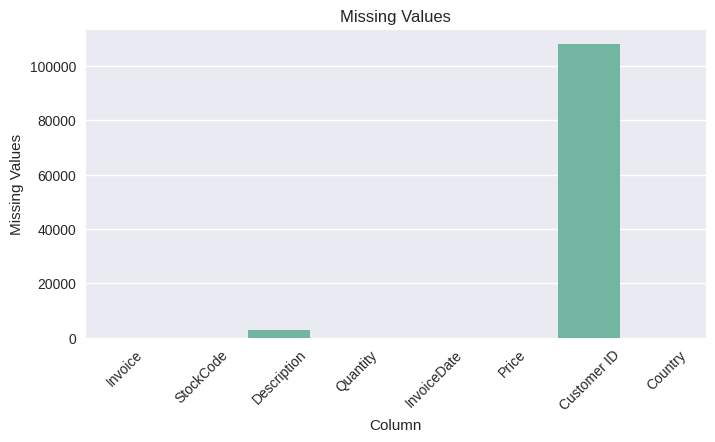

In [10]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=missing_df,
    x='Column',
    y='Missing Values'
)

plt.xticks(rotation=45)
plt.title("Missing Values")
plt.show()

In [11]:
duplicate=df.duplicated().sum()
print("Duplicate Rows: ",duplicate)

Duplicate Rows:  6865


In [12]:
df.nunique()

Invoice        28816
StockCode       4632
Description     4681
Quantity         825
InvoiceDate    25296
Price           1606
Customer ID     4383
Country           40
dtype: int64

In [13]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

In [14]:
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])

In [15]:
df.info(
    
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [16]:
print(df.memory_usage(deep=True))

Index               132
Invoice        19120776
StockCode      20431267
Description    39656441
Quantity        4203688
InvoiceDate     4203688
Price           4203688
Customer ID     4203688
Country        32816216
dtype: int64


## Data Cleaning

In [17]:
print("Shape Before:", df.shape)

print("Duplicate Rows:", df.duplicated().sum())

Shape Before: (525461, 8)
Duplicate Rows: 6865


In [18]:
df.drop_duplicates(inplace=True)

In [19]:
print("Shape After:", df.shape)

print("Duplicate Rows:", df.duplicated().sum())

Shape After: (518596, 8)
Duplicate Rows: 0


In [20]:
df.dropna(subset=['Description'], inplace=True)

In [21]:
df['Description'].isnull().sum()

np.int64(0)

In [22]:
df.dropna(subset=['Customer ID'], inplace=True)

In [23]:
df['Customer ID']=df['Customer ID'].astype(int)

Check cancelled orders


In [24]:
cancelled = df[df['Invoice'].astype(str).str.startswith('C')]

print(cancelled.shape)

(9816, 8)


In [25]:
print("Cancelled Orders:",
      df['Invoice'].astype(str).str.startswith('C').sum())

Cancelled Orders: 9816


In [26]:
df = df[
    ~df['Invoice'].astype(str).str.startswith('C')
]

In [27]:
df[df['Quantity'] <= 0].shape

(0, 8)

In [28]:
df[df['Price'] <= 0].shape

(31, 8)

In [29]:
df = df[df['Price'] > 0]

In [30]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID             int64
Country                object
dtype: object

In [31]:
df.reset_index(drop=True, inplace=True)

In [32]:
print("="*50)
print("Dataset Validation")
print("="*50)

print("Shape :", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicates")
print(df.duplicated().sum())

print("\nNegative Quantity")
print((df['Quantity'] <= 0).sum())

print("\nNegative Price")
print((df['Price'] <= 0).sum())

print("\nCancelled Orders")
print(df['Invoice'].astype(str).str.startswith('C').sum())

Dataset Validation
Shape : (400916, 8)

Missing Values
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

Duplicates
0

Negative Quantity
0

Negative Price
0

Cancelled Orders
0


In [33]:
print("="*40)
print("Clean Dataset Summary")
print("="*40)

print(f"Rows            : {df.shape[0]}")
print(f"Columns         : {df.shape[1]}")
print(f"Invoices        : {df['Invoice'].nunique()}")
print(f"Products        : {df['StockCode'].nunique()}")
print(f"Customers       : {df['Customer ID'].nunique()}")
print(f"Countries       : {df['Country'].nunique()}")

Clean Dataset Summary
Rows            : 400916
Columns         : 8
Invoices        : 19213
Products        : 4017
Customers       : 4312
Countries       : 37


## Feature Engineering

In [34]:
df['Revenue']=df['Quantity'] * df['Price']
df[['Revenue','Quantity','Price']].shape

(400916, 3)

In [35]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [36]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

In [37]:
df['MonthName'] = df['InvoiceDate'].dt.month_name()

df[['InvoiceDate', 'MonthName']].head()

,InvoiceDate,MonthName
0,2009-12-01 07:45:00,December
1,2009-12-01 07:45:00,December
2,2009-12-01 07:45:00,December
3,2009-12-01 07:45:00,December
4,2009-12-01 07:45:00,December


In [38]:
df['DayName'] = df['InvoiceDate'].dt.day_name()

df[['InvoiceDate', 'DayName']].head()

,InvoiceDate,DayName
0,2009-12-01 07:45:00,Tuesday
1,2009-12-01 07:45:00,Tuesday
2,2009-12-01 07:45:00,Tuesday
3,2009-12-01 07:45:00,Tuesday
4,2009-12-01 07:45:00,Tuesday


In [39]:
df['Quarter'] = df['InvoiceDate'].dt.quarter

In [40]:
df['Week'] = df['InvoiceDate'].dt.isocalendar().week.astype(int)

In [41]:
df['Weekend'] = df['DayName'].isin(['Saturday', 'Sunday'])

In [42]:
df['Weekend'] = df['Weekend'].map({
    True: 'Weekend',
    False: 'Weekday'
})

In [43]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)
df['YearMonth'].head()

0    2009-12
1    2009-12
2    2009-12
3    2009-12
4    2009-12
Name: YearMonth, dtype: object

In [44]:
def session(hour):
    
    if 5 <= hour < 12:
        return 'Morning'
    
    elif 12 <= hour < 17:
        return 'Afternoon'
    
    elif 17 <= hour < 21:
        return 'Evening'
    
    else:
        return 'Night'

df['TimeOfDay'] = df['Hour'].apply(session)

In [45]:
df[['Hour', 'TimeOfDay']].head()

,Hour,TimeOfDay
0,7,Morning
1,7,Morning
2,7,Morning
3,7,Morning
4,7,Morning


In [46]:
df['Customer ID'] = df['Customer ID'].astype(str)

In [47]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Hour,MonthName,DayName,Quarter,Week,Weekend,YearMonth,TimeOfDay
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009,12,1,7,December,Tuesday,4,49,Weekday,2009-12,Morning
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,1,7,December,Tuesday,4,49,Weekday,2009-12,Morning
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,1,7,December,Tuesday,4,49,Weekday,2009-12,Morning
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009,12,1,7,December,Tuesday,4,49,Weekday,2009-12,Morning
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009,12,1,7,December,Tuesday,4,49,Weekday,2009-12,Morning


In [48]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400916 entries, 0 to 400915
Data columns (total 20 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      400916 non-null  object        
 1   StockCode    400916 non-null  object        
 2   Description  400916 non-null  object        
 3   Quantity     400916 non-null  int64         
 4   InvoiceDate  400916 non-null  datetime64[ns]
 5   Price        400916 non-null  float64       
 6   Customer ID  400916 non-null  object        
 7   Country      400916 non-null  object        
 8   Revenue      400916 non-null  float64       
 9   Year         400916 non-null  int32         
 10  Month        400916 non-null  int32         
 11  Day          400916 non-null  int32         
 12  Hour         400916 non-null  int32         
 13  MonthName    400916 non-null  object        
 14  DayName      400916 non-null  object        
 15  Quarter      400916 non-null  int3

In [49]:
new_features = [
    'Revenue',
    'Year',
    'Month',
    'MonthName',
    'Quarter',
    'Week',
    'Day',
    'DayName',
    'Hour',
    'Weekend',
    'YearMonth',
    'TimeOfDay'
]

df[new_features].head()

,Revenue,Year,Month,MonthName,Quarter,Week,Day,DayName,Hour,Weekend,YearMonth,TimeOfDay
0,83.40,2009,12,December,4,49,1,Tuesday,7,Weekday,2009-12,Morning
1,81.00,2009,12,December,4,49,1,Tuesday,7,Weekday,2009-12,Morning
2,81.00,2009,12,December,4,49,1,Tuesday,7,Weekday,2009-12,Morning
3,100.80,2009,12,December,4,49,1,Tuesday,7,Weekday,2009-12,Morning
4,30.00,2009,12,December,4,49,1,Tuesday,7,Weekday,2009-12,Morning


In [50]:
print("Dataset Shape:", df.shape)

Dataset Shape: (400916, 20)


## Exploratory Data Analysis (EDA)

In [51]:
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nData Types")
print(df.dtypes)


  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price Customer ID         Country  Revenue  Year  \
0 2009-12-01 07:45:00   6.95       13085  United Kingdom    83.40  2009   
1 2009-12-01 07:45:00   6.75       13085  United Kingdom    81.00  2009   
2 2009-12-01 07:45:00   6.75       13085  United Kingdom    81.00  2009   
3 2009-12-01 07:45:00   2.10       13085  United Kingdom   100.80  2009   
4 2009-12-01 07:45:00   1.25       13085  United Kingdom    30.00  2009   

   Month  Day  Hour MonthName  DayName  Quarter  Week  Weekend YearMonth  \
0     12    1     7  December  Tuesday        4    4

In [52]:
df[['Quantity','Price','Revenue']].describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,400916.00,13.77,97.64,1.00,2.00,5.00,12.00,19152.00
Price,400916.00,3.31,35.05,0.00,1.25,1.95,3.75,10953.50
Revenue,400916.00,21.95,77.76,0.00,5.00,12.50,19.50,15818.40


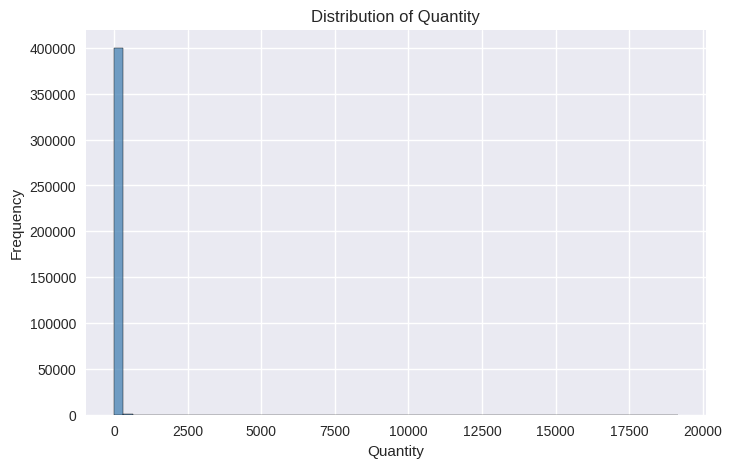

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(df['Quantity'], bins=60, color='steelblue')

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

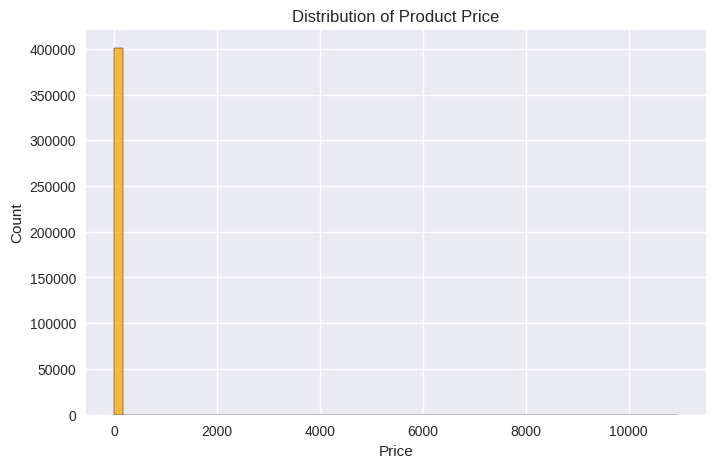

In [54]:
plt.figure(figsize=(8,5))

sns.histplot(df['Price'], bins=60, color='orange')

plt.title("Distribution of Product Price")
plt.xlabel("Price")
plt.show()

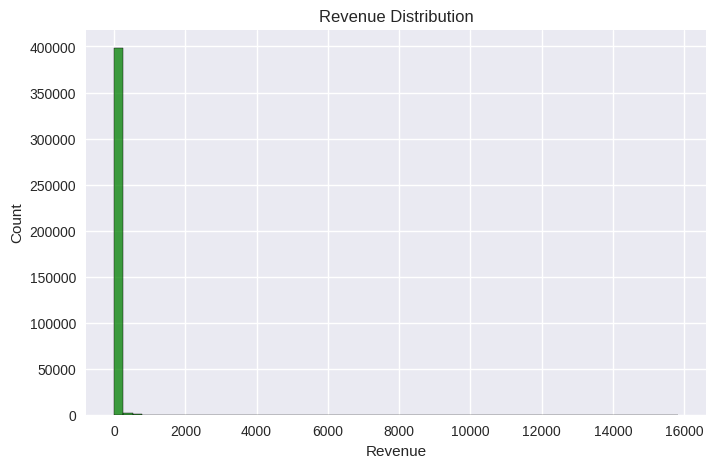

In [55]:
plt.figure(figsize=(8,5))

sns.histplot(df['Revenue'], bins=60, color='green')

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.show()

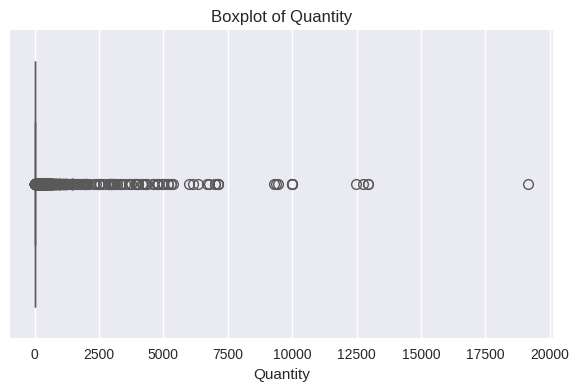

In [56]:
plt.figure(figsize=(7,4))

sns.boxplot(x=df['Quantity'])

plt.title("Boxplot of Quantity")
plt.show()

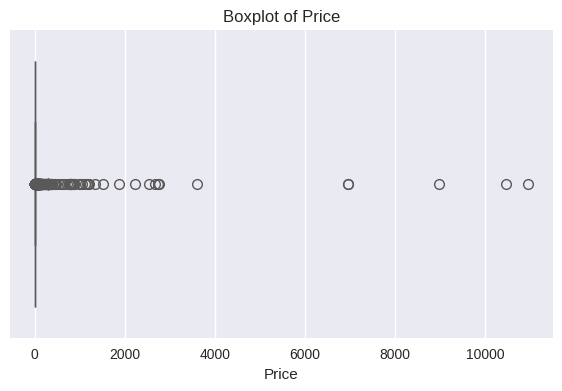

In [57]:
plt.figure(figsize=(7,4))

sns.boxplot(x=df['Price'])

plt.title("Boxplot of Price")
plt.show()

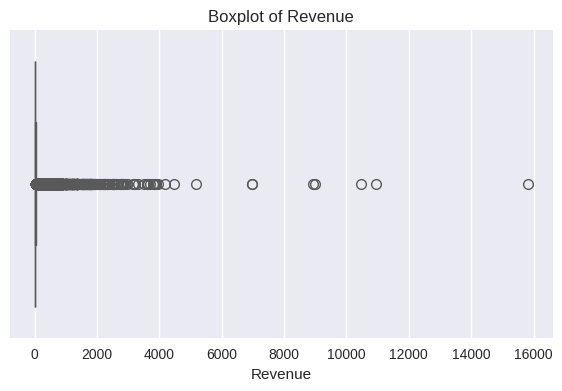

In [58]:
plt.figure(figsize=(7,4))

sns.boxplot(x=df['Revenue'])

plt.title("Boxplot of Revenue")
plt.show()

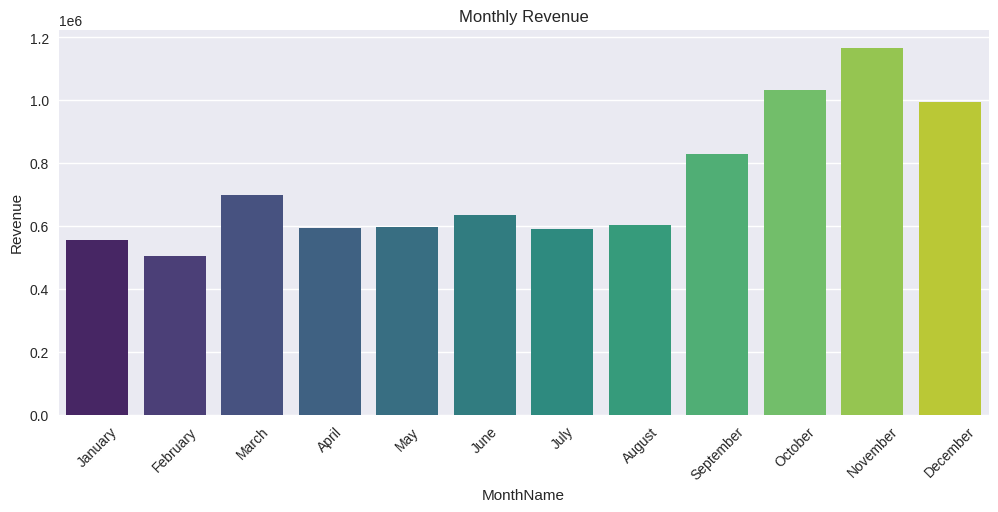

In [59]:
monthly_sales = df.groupby('MonthName')['Revenue'].sum()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,5))

sns.barplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    palette='viridis'
)

plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.ylabel("Revenue")
plt.show()

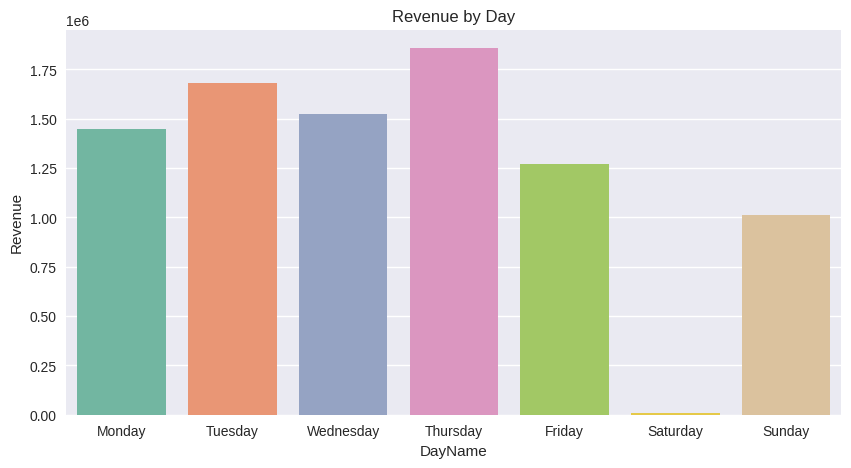

In [60]:
day_order = ['Monday','Tuesday','Wednesday','Thursday',
             'Friday','Saturday','Sunday']

day_sales = df.groupby('DayName')['Revenue'].sum().reindex(day_order)

plt.figure(figsize=(10,5))

sns.barplot(
    x=day_sales.index,
    y=day_sales.values,
    palette='Set2'
)

plt.title("Revenue by Day")
plt.ylabel("Revenue")
plt.show()

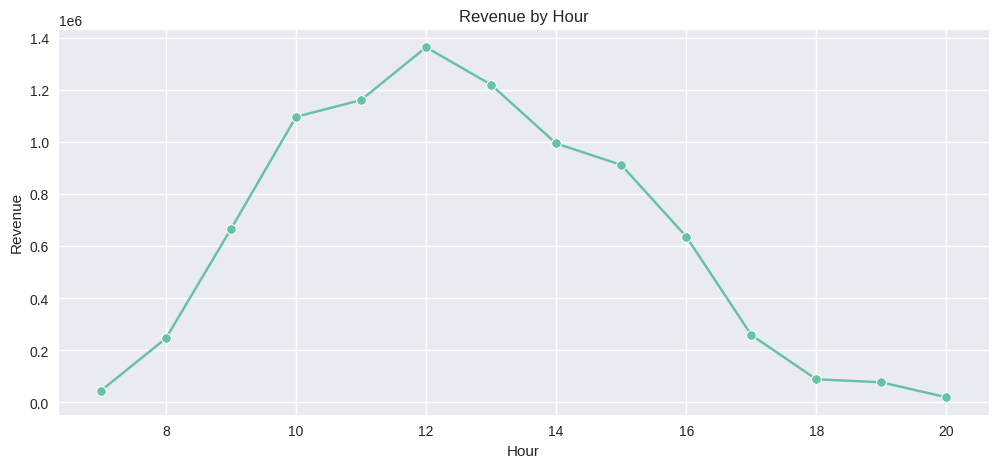

In [61]:
hourly_sales = df.groupby('Hour')['Revenue'].sum()

plt.figure(figsize=(12,5))

sns.lineplot(
    x=hourly_sales.index,
    y=hourly_sales.values,
    marker='o'
)

plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

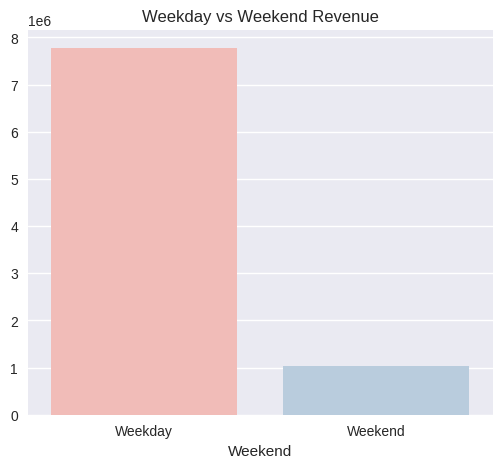

In [62]:
week_sales = df.groupby('Weekend')['Revenue'].sum()

plt.figure(figsize=(6,5))

sns.barplot(
    x=week_sales.index,
    y=week_sales.values,
    palette='Pastel1'
)

plt.title("Weekday vs Weekend Revenue")
plt.show()

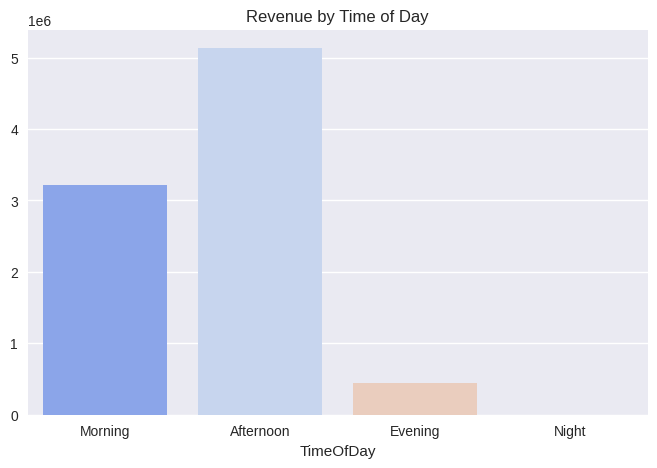

In [63]:
tod = df.groupby('TimeOfDay')['Revenue'].sum()

order = ['Morning','Afternoon','Evening','Night']

tod = tod.reindex(order)

plt.figure(figsize=(8,5))

sns.barplot(
    x=tod.index,
    y=tod.values,
    palette='coolwarm'
)

plt.title("Revenue by Time of Day")
plt.show()

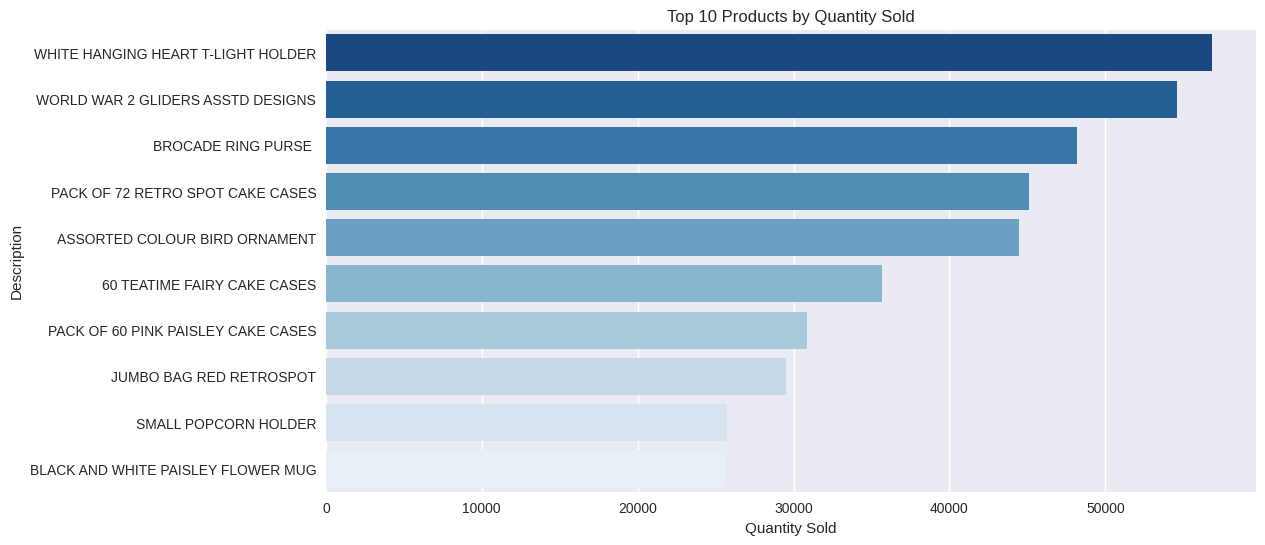

In [64]:
top_products = (df.groupby('Description')['Quantity']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette='Blues_r'
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.show()

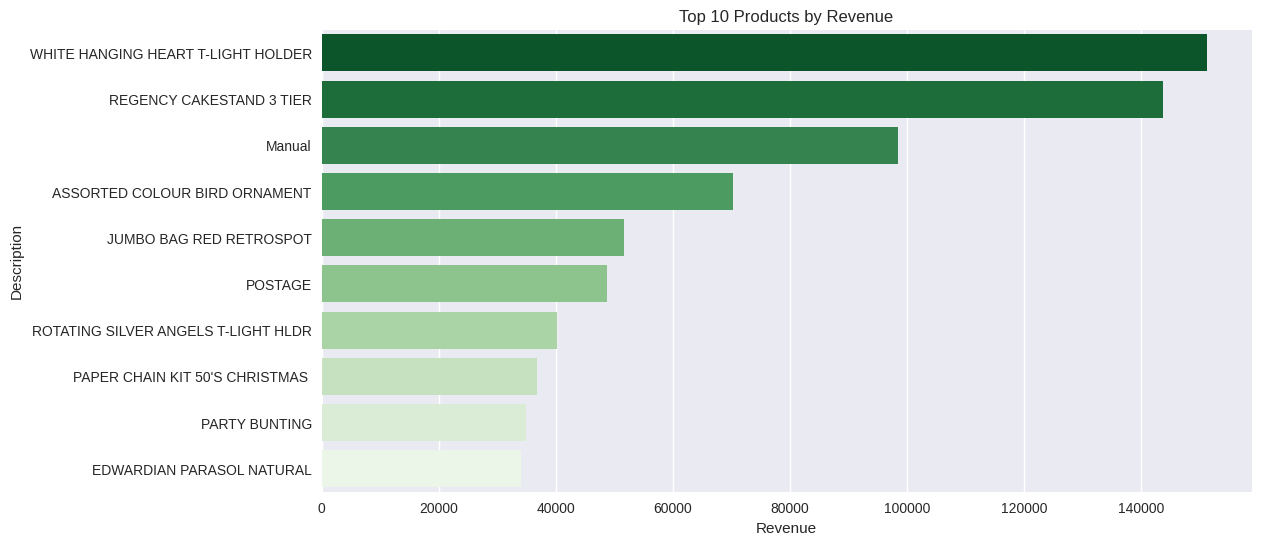

In [65]:
top_revenue = (df.groupby('Description')['Revenue']
                 .sum()
                 .sort_values(ascending=False)
                 .head(10))

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_revenue.values,
    y=top_revenue.index,
    palette='Greens_r'
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.show()

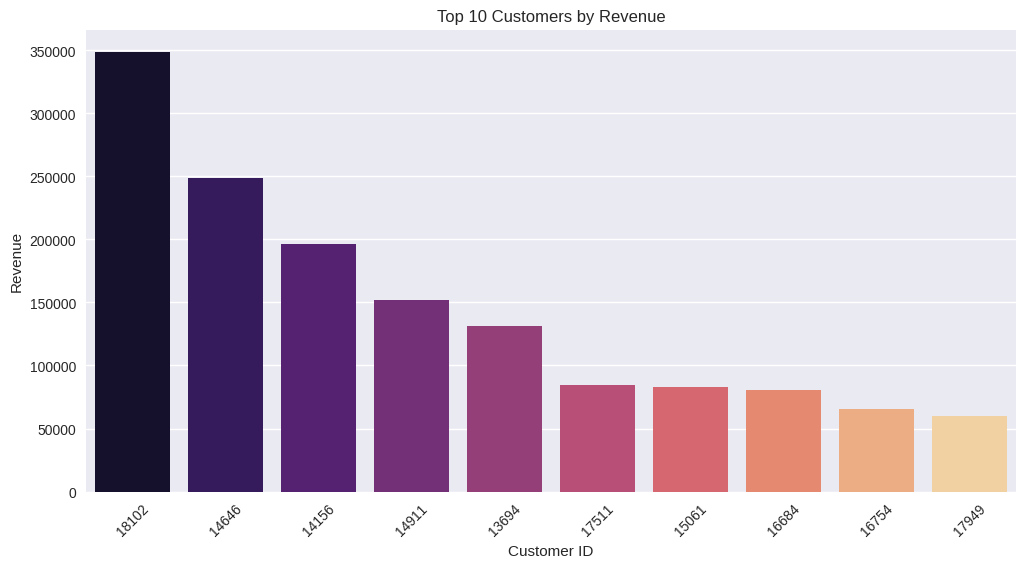

In [66]:
top_customers = (df.groupby('Customer ID')['Revenue']
                   .sum()
                   .sort_values(ascending=False)
                   .head(10))

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.index.astype(str),
    y=top_customers.values,
    palette='magma'
)

plt.xticks(rotation=45)
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

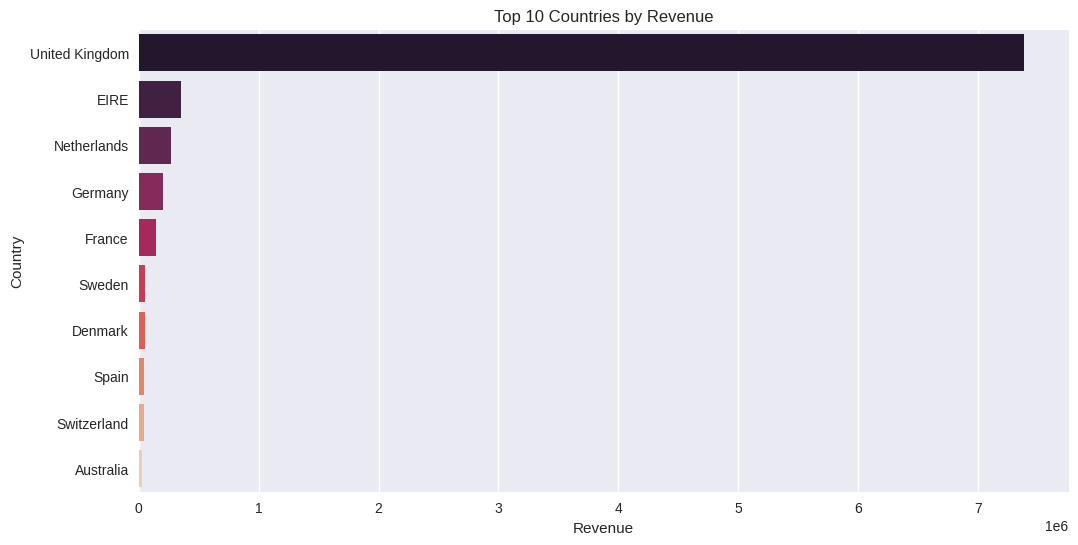

In [67]:
country_sales = (df.groupby('Country')['Revenue']
                   .sum()
                   .sort_values(ascending=False)
                   .head(10))

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_sales.values,
    y=country_sales.index,
    palette='rocket'
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.show()

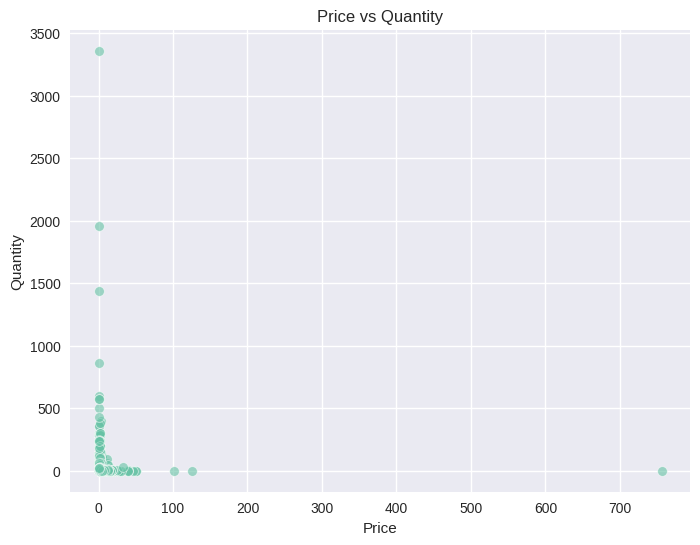

In [68]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='Price',
    y='Quantity',
    alpha=0.6
)

plt.title("Price vs Quantity")
plt.show()

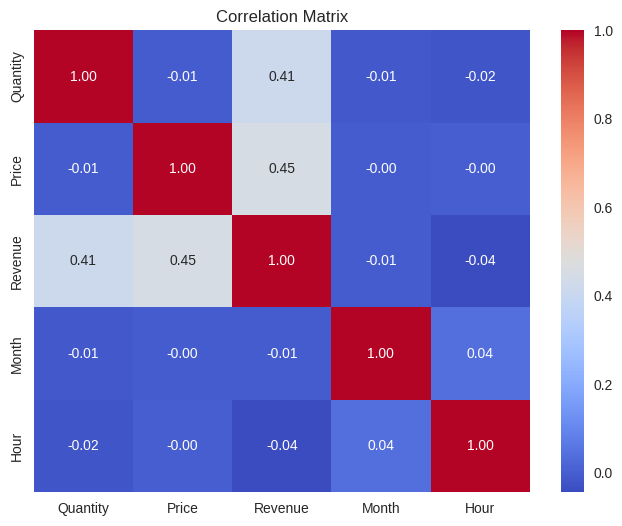

In [69]:
plt.figure(figsize=(8,6))

corr = df[['Quantity','Price','Revenue','Month','Hour']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

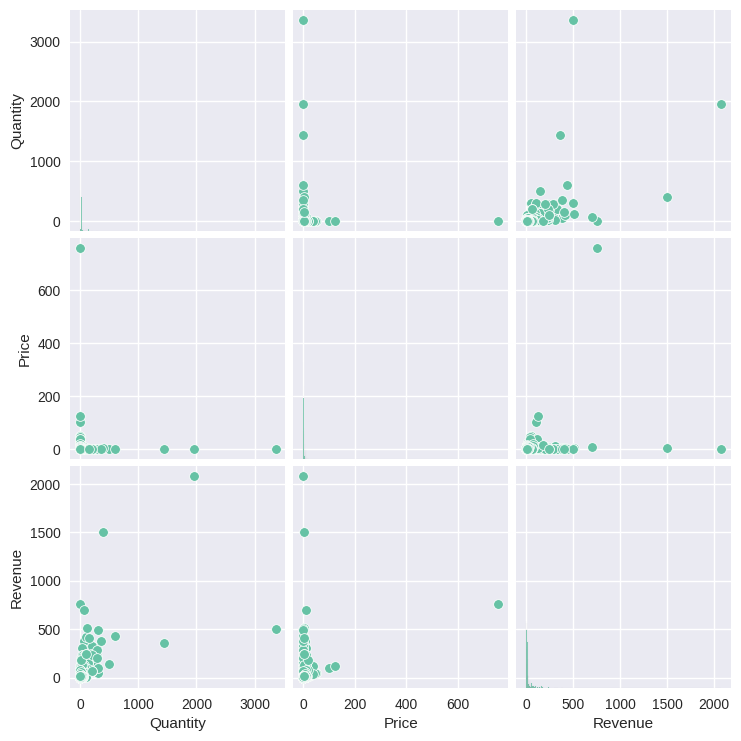

In [70]:
sample_df = df[['Quantity', 'Price', 'Revenue']].sample(3000, random_state=42)

sns.pairplot(sample_df)

plt.show()

 ## RFM Analysis

In [71]:
# Latest transaction date
print(df['InvoiceDate'].max())

2010-12-09 20:01:00


In [72]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2010-12-10 20:01:00


In [73]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
})

In [74]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,165,11,372.86
12347,3,2,1323.32
12348,74,1,222.16
12349,43,3,2671.14
12351,11,1,300.93


In [75]:
print(rfm.shape)

(4312, 3)


In [76]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4312.00,91.17,96.86,1.00,18.00,53.00,136.00,374.00
Frequency,4312.00,4.46,8.17,1.00,1.00,2.00,5.00,205.00
Monetary,4312.00,2040.41,8911.76,2.95,307.19,701.62,1714.93,349164.35


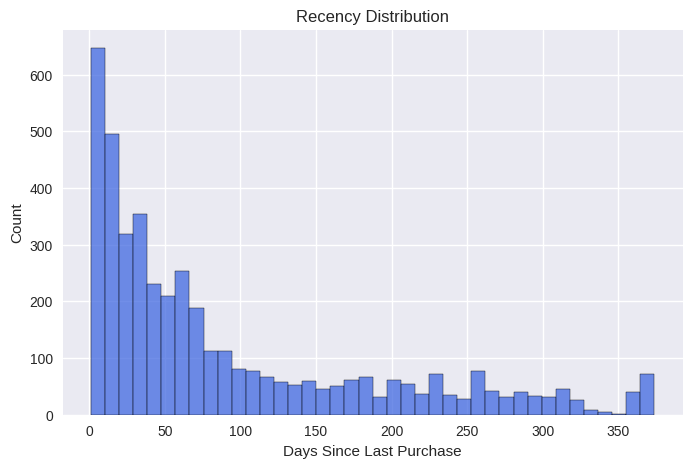

In [77]:
plt.figure(figsize=(8,5))

sns.histplot(rfm['Recency'], bins=40, color='royalblue')

plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.show()

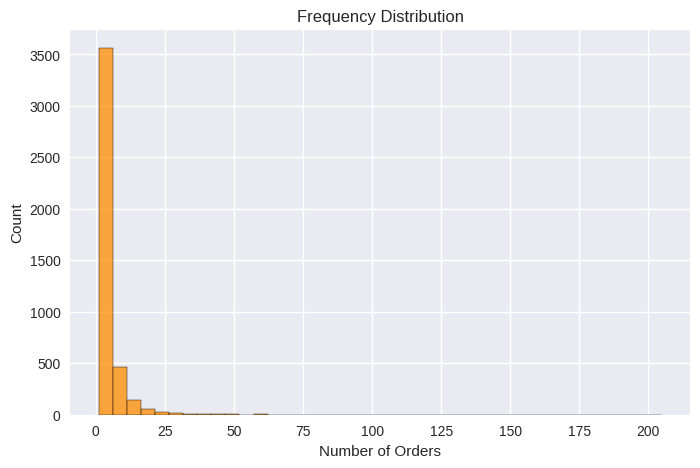

In [78]:
plt.figure(figsize=(8,5))

sns.histplot(rfm['Frequency'], bins=40, color='darkorange')

plt.title("Frequency Distribution")
plt.xlabel("Number of Orders")
plt.show()

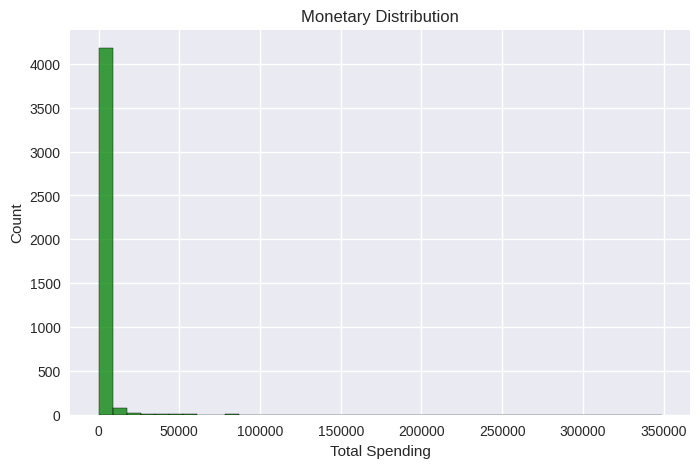

In [79]:
plt.figure(figsize=(8,5))

sns.histplot(rfm['Monetary'], bins=40, color='green')

plt.title("Monetary Distribution")
plt.xlabel("Total Spending")
plt.show()

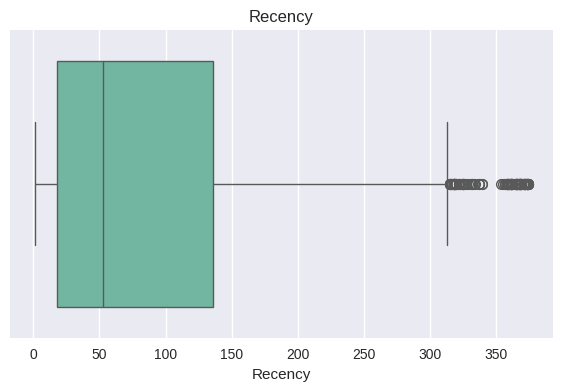

In [80]:
plt.figure(figsize=(7,4))

sns.boxplot(x=rfm['Recency'])

plt.title("Recency")
plt.show()

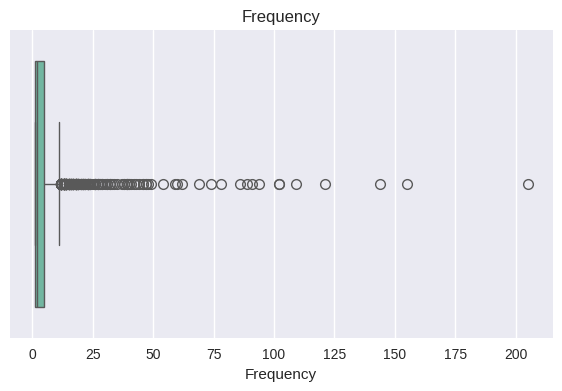

In [81]:
plt.figure(figsize=(7,4))

sns.boxplot(x=rfm['Frequency'])

plt.title("Frequency")
plt.show()

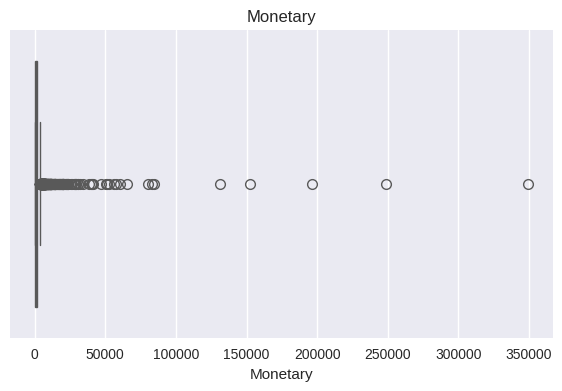

In [82]:
plt.figure(figsize=(7,4))

sns.boxplot(x=rfm['Monetary'])

plt.title("Monetary")
plt.show()

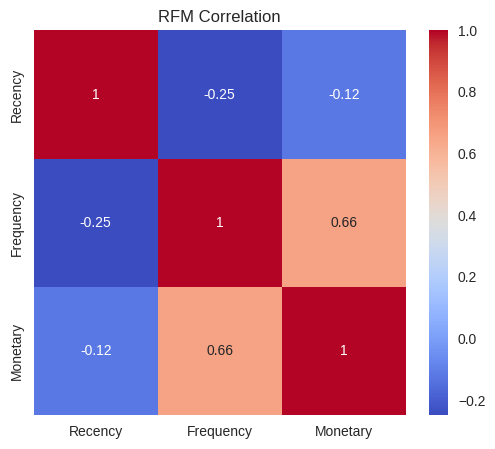

In [83]:
plt.figure(figsize=(6,5))

sns.heatmap(rfm.corr(), annot=True, cmap='coolwarm')

plt.title("RFM Correlation")
plt.show()

In [84]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

In [85]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

In [86]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [87]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346,165,11,372.86,1,4,2,142
12347,3,2,1323.32,4,2,3,423
12348,74,1,222.16,2,1,1,211
12349,43,3,2671.14,3,3,4,334
12351,11,1,300.93,4,1,1,411


In [88]:
def segment(row):

    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    # Highest value customers
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    # Frequent and valuable customers
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'

    # Customers who recently purchased but have low history
    elif r >= 4 and f <= 2:
        return 'Recent Customers'

    # Customers who purchased before but are becoming inactive
    elif r <= 2 and f >= 3:
        return 'At Risk'

    # High spenders who may not purchase frequently
    elif m >= 4:
        return 'Big Spenders'

    # Customers with very low engagement
    elif r == 1 and f <= 2 and m <= 2:
        return 'Lost Customers'

    # Remaining customers
    else:
        return 'Potential Customers'


rfm['Segment'] = rfm.apply(segment, axis=1)

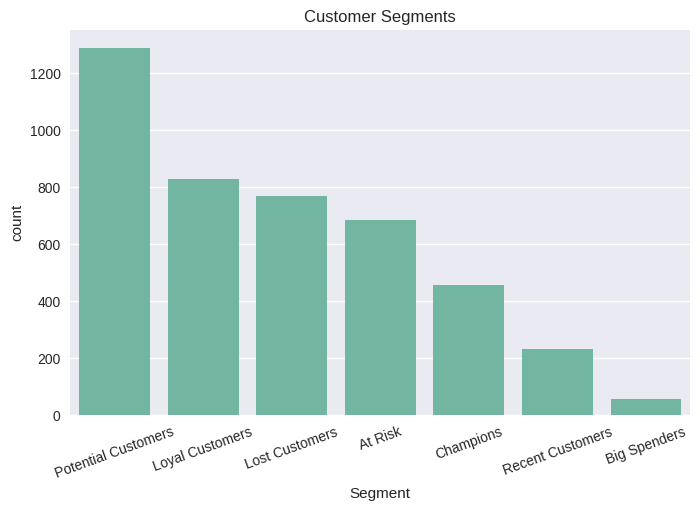

In [89]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x='Segment',
    order=rfm['Segment'].value_counts().index
)

plt.xticks(rotation=20)
plt.title("Customer Segments")
plt.show()

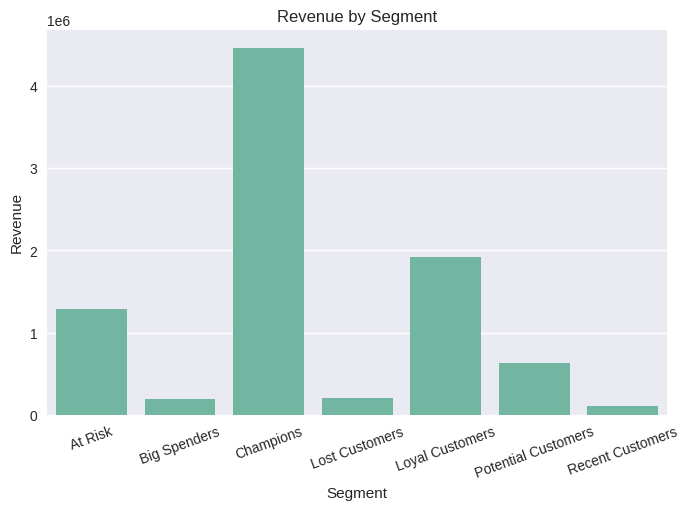

In [90]:
segment_sales = rfm.groupby('Segment')['Monetary'].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.xticks(rotation=20)
plt.title("Revenue by Segment")
plt.ylabel("Revenue")
plt.show()

In [91]:
top10 = rfm.sort_values(
    by='Monetary',
    ascending=False
).head(10)

top10

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
18102,1,89,349164.35,4,4,4,444,Champions
14646,10,78,248396.50,4,4,4,444,Champions
14156,7,102,196549.74,4,4,4,444,Champions
14911,1,205,152121.22,4,4,4,444,Champions
13694,9,94,131443.19,4,4,4,444,Champions
17511,3,31,84541.17,4,4,4,444,Champions
15061,3,86,83284.38,4,4,4,444,Champions
16684,15,27,80489.21,4,4,4,444,Champions
16754,8,29,65500.07,4,4,4,444,Champions


In [92]:
rfm.to_csv("RFM_Customers.csv")

In [93]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12346,165,11,372.86,1,4,2,142,At Risk
12347,3,2,1323.32,4,2,3,423,Recent Customers
12348,74,1,222.16,2,1,1,211,Potential Customers
12349,43,3,2671.14,3,3,4,334,Loyal Customers
12351,11,1,300.93,4,1,1,411,Recent Customers


In [94]:
rfm['Segment'].value_counts()

Segment
Potential Customers    1288
Loyal Customers         829
Lost Customers          767
At Risk                 685
Champions               457
Recent Customers        232
Big Spenders             54
Name: count, dtype: int64

## Customer Segmentation using K-Means Clustering

In [95]:
rfm_model = rfm[['Recency','Frequency','Monetary']].copy()

rfm_model.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,165,11,372.86
12347,3,2,1323.32
12348,74,1,222.16
12349,43,3,2671.14
12351,11,1,300.93


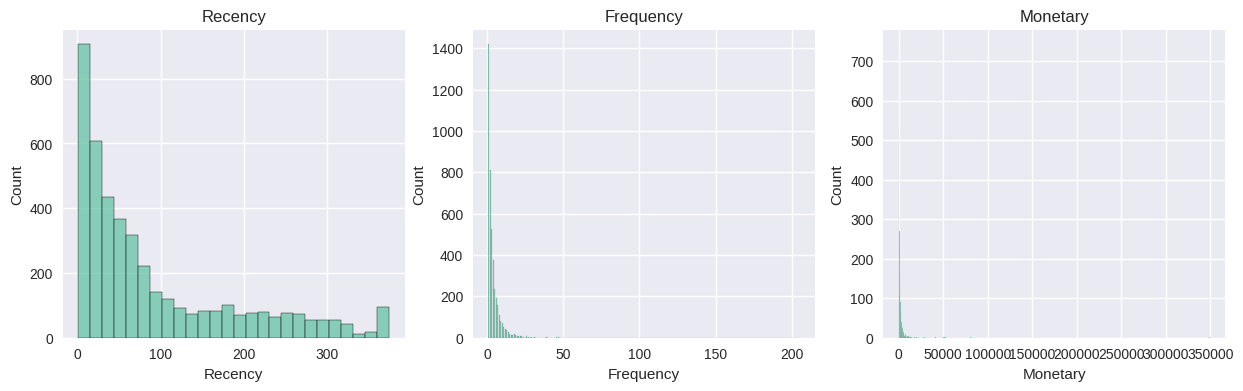

In [96]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

sns.histplot(rfm_model['Recency'], ax=axes[0])
axes[0].set_title("Recency")

sns.histplot(rfm_model['Frequency'], ax=axes[1])
axes[1].set_title("Frequency")

sns.histplot(rfm_model['Monetary'], ax=axes[2])
axes[2].set_title("Monetary")

plt.show()

In [97]:
rfm_log = np.log1p(rfm_model)

rfm_log.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,5.11,2.48,5.92
12347,1.39,1.10,7.19
12348,4.32,0.69,5.41
12349,3.78,1.39,7.89
12351,2.48,0.69,5.71


In [98]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency','Frequency','Monetary']
)

rfm_scaled.head()

,Recency,Frequency,Monetary
0,0.97,1.61,-0.53
1,-1.90,-0.39,0.45
2,0.36,-0.98,-0.94
3,-0.06,0.02,1.00
4,-1.05,-0.98,-0.70


In [99]:
from sklearn.cluster import KMeans

inertia = []

K = range(1,11)

for k in K:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    
    inertia.append(kmeans.inertia_)

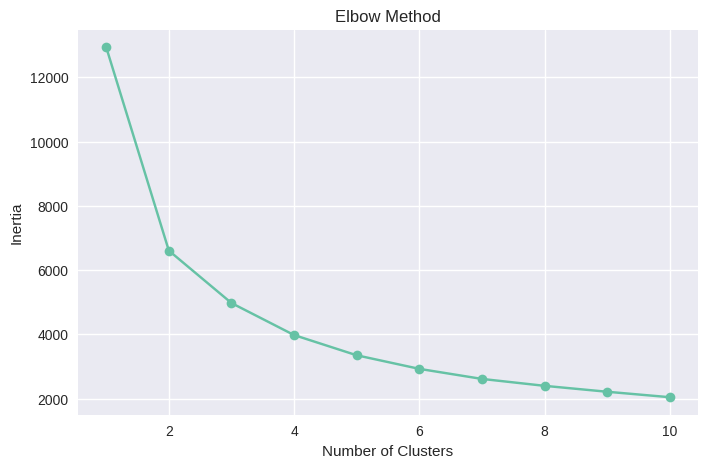

In [100]:
plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [101]:
from sklearn.metrics import silhouette_score


for k in range(2,9):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    print(
        "Clusters:",
        k,
        "Score:",
        round(score,3)
    )

Clusters: 2 Score: 0.422
Clusters: 3 Score: 0.328
Clusters: 4 Score: 0.331
Clusters: 5 Score: 0.319
Clusters: 6 Score: 0.312
Clusters: 7 Score: 0.307
Clusters: 8 Score: 0.279


In [102]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [103]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Cluster
Customer ID,,,,,,,,,
12346,165,11,372.86,1,4,2,142,At Risk,0
12347,3,2,1323.32,4,2,3,423,Recent Customers,1
12348,74,1,222.16,2,1,1,211,Potential Customers,0
12349,43,3,2671.14,3,3,4,334,Loyal Customers,1
12351,11,1,300.93,4,1,1,411,Recent Customers,0


In [104]:
rfm['Cluster'].value_counts()

Cluster
0    2670
1    1642
Name: count, dtype: int64

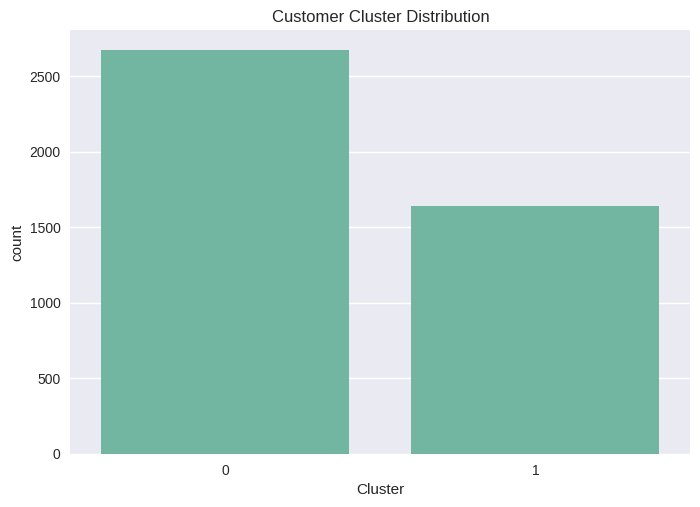

In [105]:
sns.countplot(
    data=rfm,
    x='Cluster'
)

plt.title("Customer Cluster Distribution")
plt.show()

In [106]:
cluster_summary = (
    rfm.groupby('Cluster')
    [['Recency','Frequency','Monetary']]
    .mean()
    .round(2)
)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,128.99,1.73,517.66
1,29.68,8.88,4516.50


In [107]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

pca_df = pd.DataFrame(
    rfm_pca,
    columns=['PC1','PC2']
)

pca_df['Cluster'] = rfm['Cluster'].values

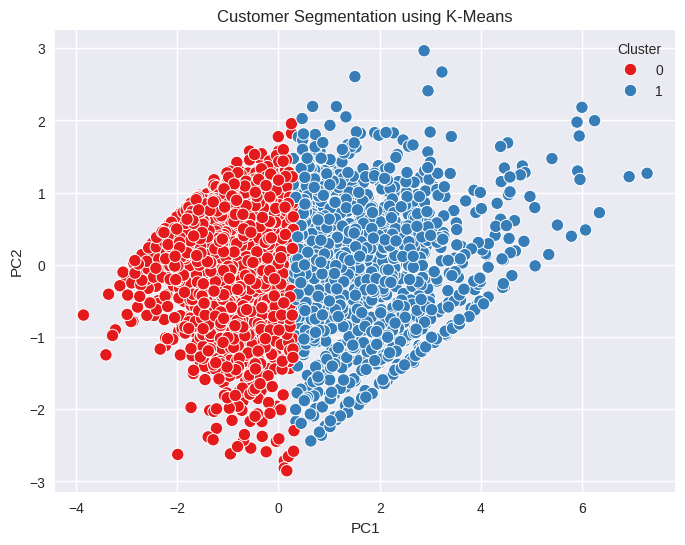

In [108]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=80
)

plt.title("Customer Segmentation using K-Means")
plt.show()